In [2]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns
from matplotlib import rcParams
import numpy as np

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data

In [3]:
df = load_multisensory_data(base_path="../data")
df.columns


Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


Index(['participant', 'perturb', 'session', 'phase', 'trial_number', 'type',
       'vis_noise', 'cursor_offset', 'time', 'lefty_pos', 'leftx_pos',
       'righty_pos', 'rightx_pos', 'cursory_pos'],
      dtype='object')

In [4]:
df["tracking_error"] = df["lefty_pos"] - df["righty_pos"]
df["tracking_mse"] = df["tracking_error"] ** 2

df["abs_offset"] = df["cursor_offset"].abs()
df["abs_tracking_error"] = df["tracking_error"].abs()

## Experimental design

In [5]:
df["offset_sign"] = df.groupby("participant")["cursor_offset"].transform(lambda x: np.sign(x.mean()))

df["tracking_error"] *= df["offset_sign"]

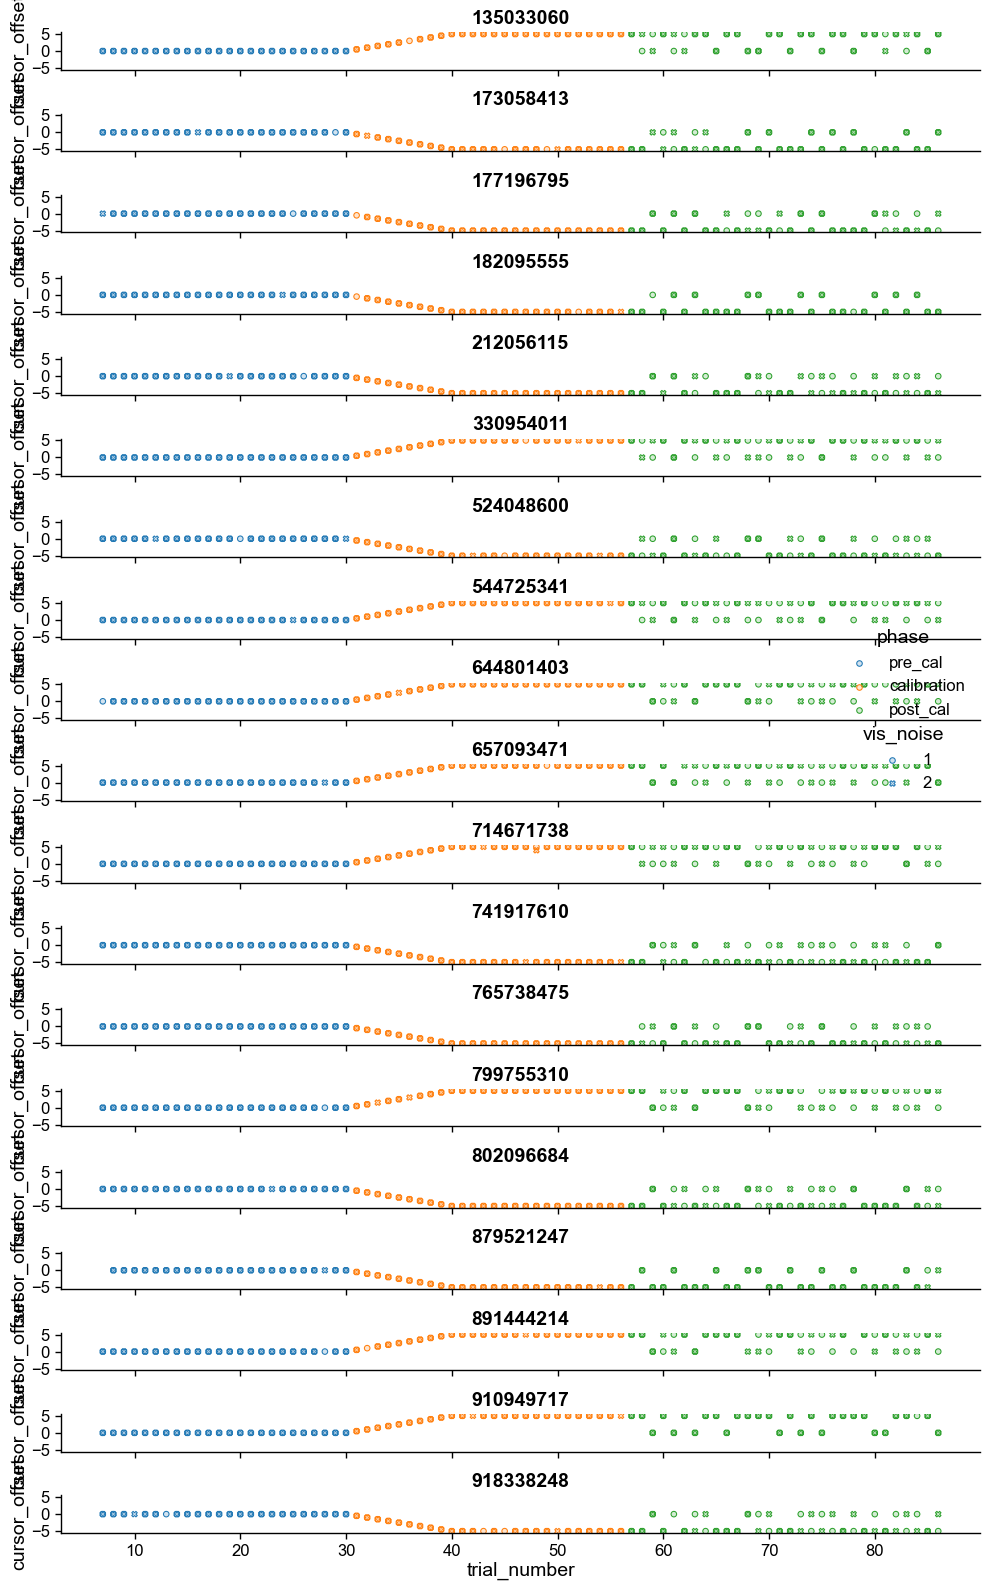

In [6]:
g = (
    so.Plot(
        df,
        x="trial_number",
        y="cursor_offset",
        color="phase",
        group="participant",
        marker="vis_noise",
    )
    .add(so.Dots(), so.Agg())
    .facet(row="participant")
    .layout(size=(10, 16))
)
g.show()

## Individual trials

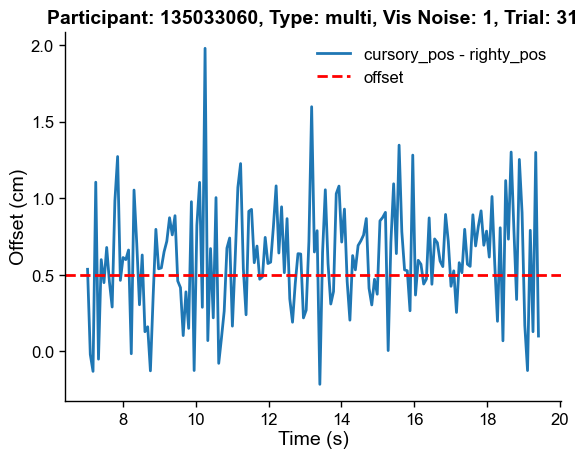

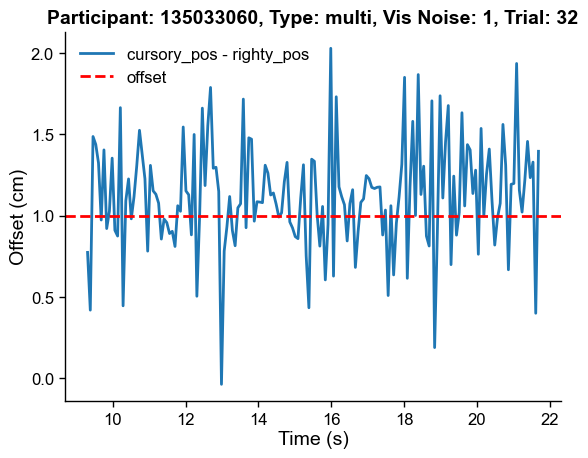

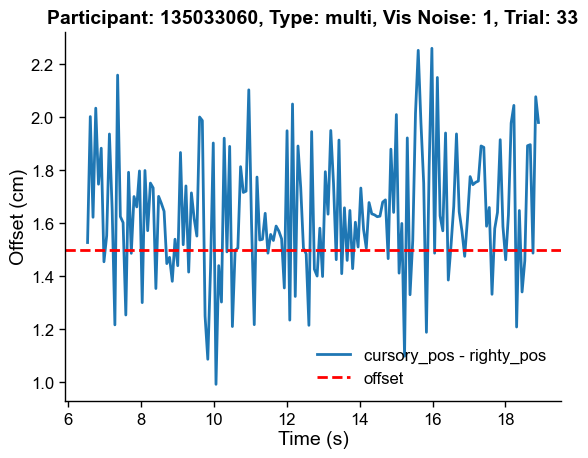

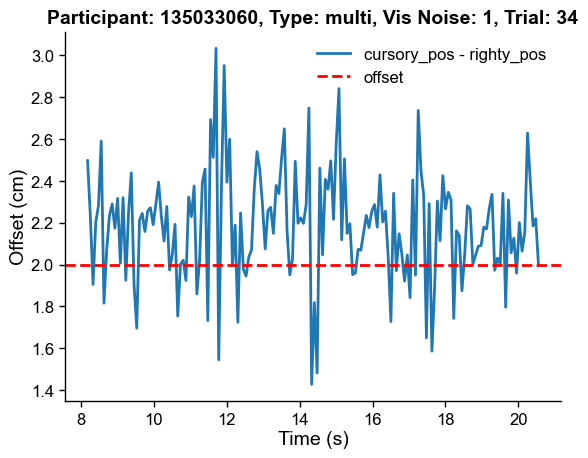

In [7]:
participant = 135033060
condition = "multi"
vis_noise = 1

sub_df = df[(df["phase"] == "calibration") & (df["participant"] == participant) & (df["type"] == condition) & (df["vis_noise"] == vis_noise)]

for i, (name, group) in enumerate(sub_df.groupby(["trial_number"])):
    offset = group["cursor_offset"].iloc[0]
    # plt.plot(group["time"], group["lefty_pos"], label="lefty_pos")
    # plt.plot(group["time"], group["righty_pos"], label="righty_pos")
    # plt.plot(group["time"], group["cursory_pos"], label="cursory_pos")
    plt.plot(group["time"], group["cursory_pos"] - group["righty_pos"], label="cursory_pos - righty_pos")
    plt.axhline(offset, color="red", linestyle="--", label="offset")
    plt.title(f"Participant: {participant}, Type: {condition}, Vis Noise: {vis_noise}, Trial: {name[0]}")
    plt.xlabel("Time (s)")
    plt.ylabel("Offset (cm)")
    plt.legend()
    plt.show()

    if i > 2:
        break

## Average tracking error

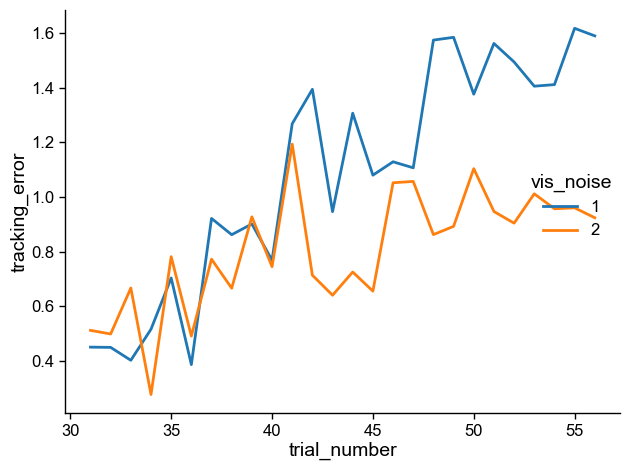

In [13]:
g = (
    so.Plot(
        df[(df["phase"].isin(["calibration"]))],
        x="trial_number",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg("median"))
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .scale(color=so.Nominal())
    # .facet(col="perturb")
)
g.show()

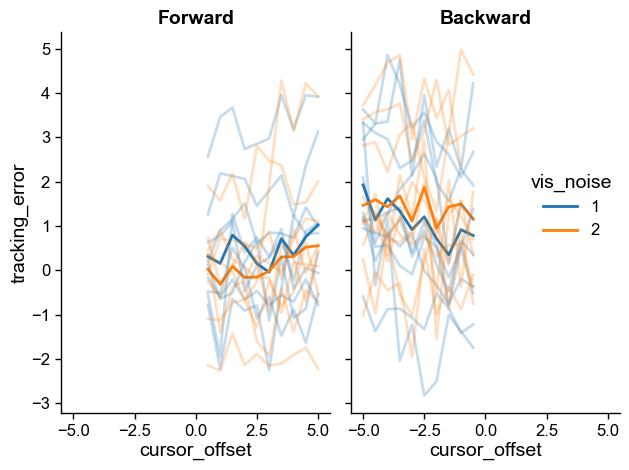

In [9]:
g = (
    so.Plot(
        df[df["phase"] == "calibration"],
        x="cursor_offset",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    .add(so.Line(alpha=0.25), so.Agg(), group="participant")
    .scale(color=so.Nominal())
    .facet(col="perturb")
)
g.show()

In [10]:
# TODO: plot difference between low and high vis noise condition per participant

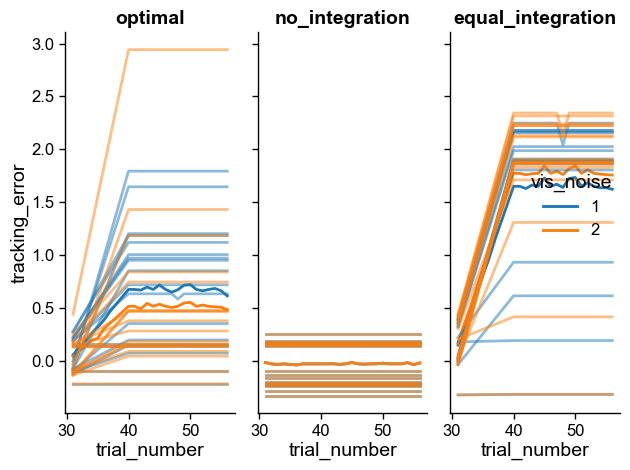

In [ ]:
sim_df = pd.concat(
    [
        pd.read_csv(
            f"../results/multisensory-simulations-calibration-{participant}_1_2_7453_1000_2500_4.csv"
        )
        for participant in df["participant"].unique()
    ]
)


In [19]:
sim_df = sim_df.reset_index(drop=True)

In [25]:

sim_df["tracking_error"] = sim_df["lefty_pos"] - (sim_df["righty_pos"] + np.random.normal(loc=0, scale=0.5, size=len(sim_df)))

sim_df["offset_sign"] = sim_df.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

sim_df["tracking_error"] *= sim_df["offset_sign"]


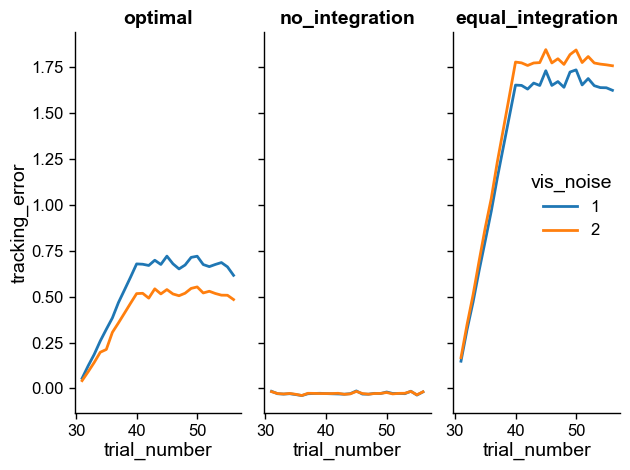

In [26]:

g = (
    so.Plot(
        sim_df[(sim_df["phase"].isin(["calibration"]))],
        x="trial_number",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .scale(color=so.Nominal())
    .facet(col="model")
)
g.show()

In [23]:
df["model"] = "data"
all_df = pd.concat([df, sim_df]).reset_index(drop=True)

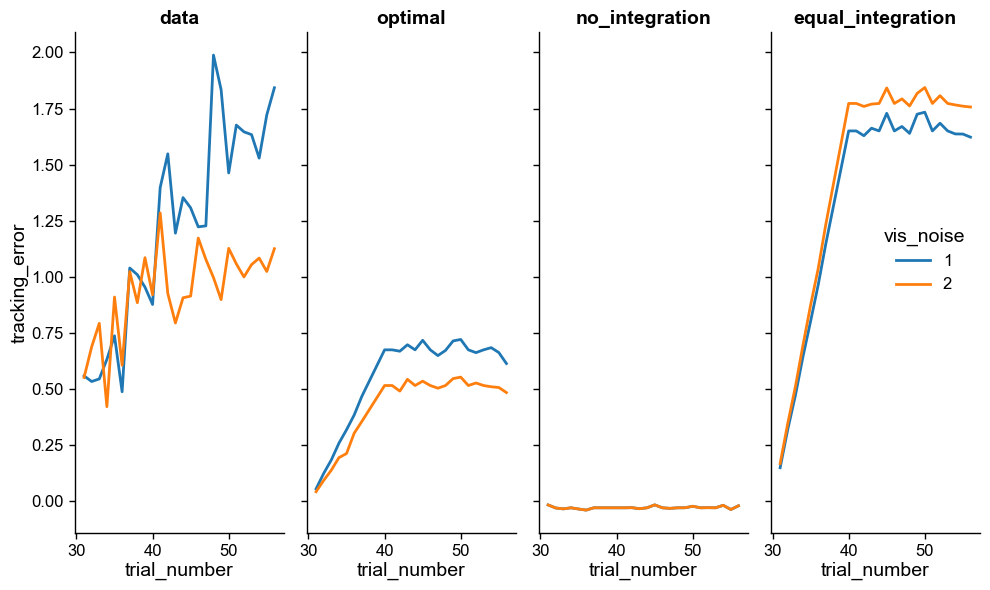

In [27]:

g = (
    so.Plot(
        all_df[(all_df["phase"].isin(["calibration"]))],
        x="trial_number",
        y="tracking_error",
        color="vis_noise",
    )
    .add(so.Line(), so.Agg())
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .scale(color=so.Nominal())
    .facet(col="model")
    .layout(size=(10, 6))
)
g.show()